# Malaria Detection — Colab Training

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mauryasameer/Malaria_detection/blob/master/notebooks/train_colab.ipynb)

Trains the ResNet-18 classifier from `malaria_detection/` on the NIH Malaria Cell Images dataset using a Colab GPU.

**Steps:** clone repo → install deps → download dataset → explore data → train → download checkpoint.


In [9]:
!git clone https://github.com/mauryasameer/Malaria_detection.git
%cd Malaria_detection
!pip install -q -r requirements.txt

Cloning into 'Malaria_detection'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 54 (delta 5), reused 31 (delta 3), pack-reused 19 (from 1)
Receiving objects: 100% (54/54), 8.25 MiB | 7.85 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/Malaria_detection/Malaria_detection


In [10]:
# Download and extract the NIH Malaria Cell Images dataset (~340MB)
!wget -q https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -O cell_images.zip
!unzip -q cell_images.zip -d data
!ls data/cell_images

Parasitized  Uninfected


## Exploratory data analysis

Quick look at the dataset before training: class balance, sample images, and image-size stats.

In [11]:
from pathlib import Path

data_root = Path("data/cell_images")
class_counts = {
    class_dir.name: len(list(class_dir.glob("*.png")))
    for class_dir in sorted(data_root.iterdir())
    if class_dir.is_dir()
}
class_counts

{'Parasitized': 13779, 'Uninfected': 13779}

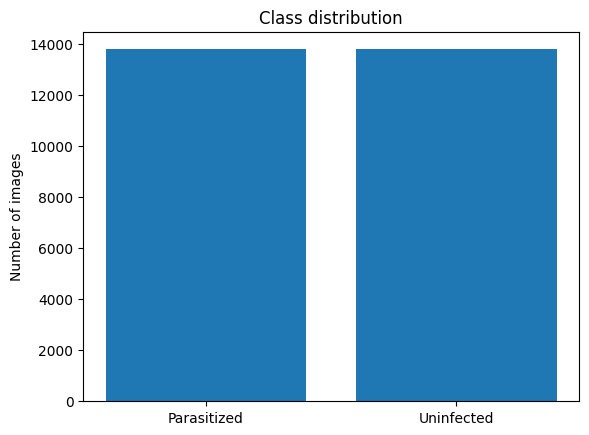

In [12]:
import matplotlib.pyplot as plt

plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class distribution")
plt.ylabel("Number of images")
plt.show()

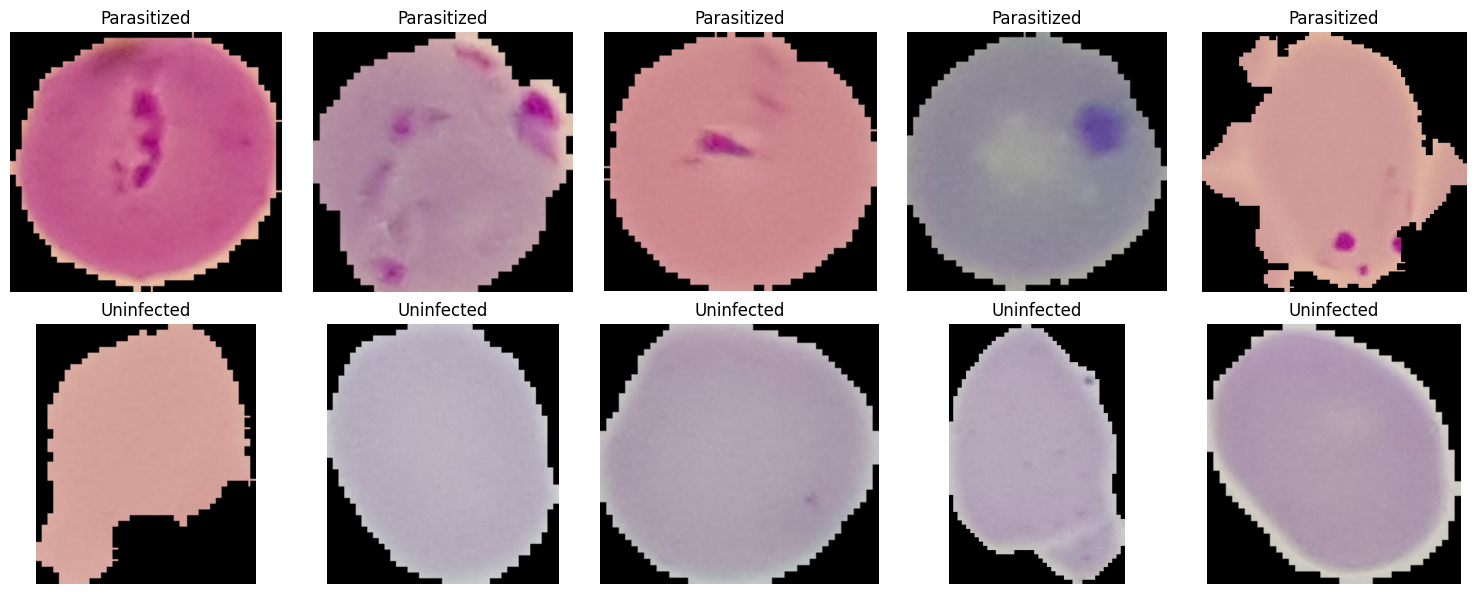

In [13]:
import random

from PIL import Image

fig, axes = plt.subplots(len(class_counts), 5, figsize=(15, 3 * len(class_counts)))
for row, class_name in enumerate(class_counts):
    sample_paths = random.sample(list((data_root / class_name).glob("*.png")), 5)
    for col, image_path in enumerate(sample_paths):
        axes[row, col].imshow(Image.open(image_path))
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

In [14]:
sample_paths = random.sample(list(data_root.rglob("*.png")), 200)
widths, heights = zip(*(Image.open(p).size for p in sample_paths))

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {sum(widths) / len(widths):.1f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {sum(heights) / len(heights):.1f}")

Width  — min: 85, max: 265, mean: 130.8
Height — min: 85, max: 346, mean: 132.7


## Train the model

In [15]:
from malaria_detection.train import train_model

metrics = train_model(
    data_dir="data/cell_images",
    output_dir="outputs",
    epochs=10,
    batch_size=64,
    lr=1e-4,
)
metrics["best_val_accuracy"]

0.9687896933405915

In [16]:
# Download the trained checkpoint + metrics — commit these into the repo's outputs/ folder
from google.colab import files

files.download("outputs/model.pt")
files.download("outputs/metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>